In [35]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, 
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from sklearn.preprocessing import OneHotEncoder

## CNN in MNIST Data

In [64]:
from tensorflow.keras.datasets import cifar10

In [65]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [81]:
cifar10_labels = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

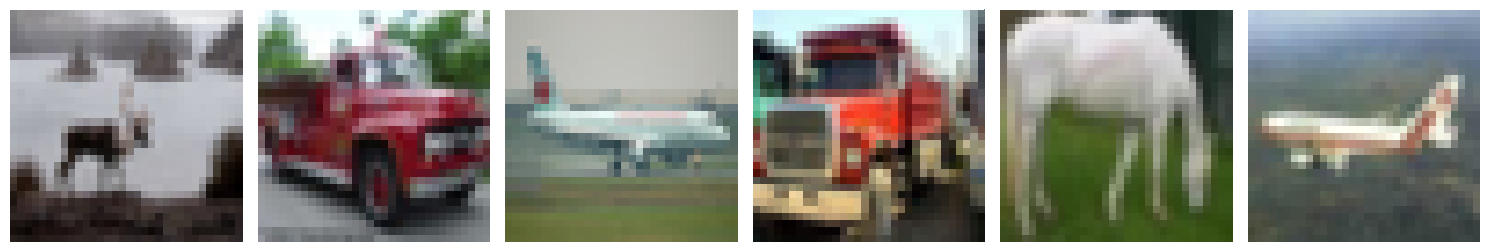

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Select 6 images (you can choose specific indices if needed)
indices = np.random.choice(len(X_train), 6, replace=False)
selected_images = [X_train[i] for i in indices]

# Create subplots
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

# Plot each image
for ax, img in zip(axes, selected_images):
    ax.imshow(img, cmap='gray')  # Display image in grayscale
    ax.axis('off')  # Turn off axes for a cleaner look

# Display the plot
plt.tight_layout()
plt.show()

In [69]:
X_train.shape

(50000, 32, 32, 3)

In [70]:
# Data Processing
# X_train = X_train.reshape(*X_train.shape, 1)
# X_test = X_test.reshape(*X_test.shape, 1)

In [71]:
# Min -max Scaling (0 -1)
X_train = X_train / 255
X_test = X_test / 255

In [72]:
# TArget Encoding with onehotencoder
onehot_enc = OneHotEncoder(sparse_output=False)
y_train_enc = onehot_enc.fit_transform(y_train.reshape(-1,1))
y_test_enc = onehot_enc.transform(y_test.reshape(-1,1))

In [73]:
inp_shape = X_train.shape[1:]
num_classes = y_test_enc.shape[1]

## Model Defination 

| Layer | Type | Configuration | Output |
|---|---|---|---|
| Input | Image/Input | 28 × 28 grayscale image | 28 × 28 = 784 pixels |
| Conv 1 | Convolution | 6 filters, 5 × 5, stride 1 | Feature maps |
| Pool 1 | Max Pooling | 2 × 2, stride 2 | Downsampled feature maps |
| Conv 2 | Convolution | 16 filters, 5 × 5, stride 1 | Feature maps |
| Pool 2 | Max Pooling | 2 × 2, stride 2 | Downsampled feature maps |
| FC 1 | Fully Connected | 120 preceptron | 120 |
| FC 2 | Fully Connected | 100 preceptron | 100 |
| Output | Fully Connected | 10 preceptron | 10 digit classes |


In [98]:
model = Sequential()

# Input Layer
model.add(Input(shape= inp_shape))

# Convo Layer 1
model.add(Conv2D(
    filters=6, kernel_size= (5,5), strides= (1,1) , padding="valid", activation="relu"
))
model.add(MaxPooling2D(pool_size=(2,2), strides= 2)) #<- Downsampling

# Convo Layer 2
model.add(Conv2D(
    filters=16, kernel_size= (5,5), strides= (1,1) , padding="valid", activation="relu"
))
model.add(MaxPooling2D(pool_size=(2,2), strides= 2)) #<- Downsampling

model.add(Flatten())

# Fully Connected Layer
# Classification Head
model.add(Dense(100, activation="relu"))
model.add(Dropout(0.25)) # Dropout
model.add(Dense(50, activation="relu"))
model.add(Dense(10, activation= "softmax"))


model.compile(
    optimizer="Adam",
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)

In [99]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,532 (189.58 KB)

 Trainable params: 48,532 (189.58 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
history = model.fit(
    X_train, y_train_enc, epochs=50, batch_size=64, validation_split=0.2, verbose=1,
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3475 - loss: 1.7658 - val_accuracy: 0.4502 - val_loss: 1.4999
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4617 - loss: 1.4759 - val_accuracy: 0.4943 - val_loss: 1.4071
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5028 - loss: 1.3785 - val_accuracy: 0.5306 - val_loss: 1.3109
Epoch 4/50
356/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5302 - loss: 1.3067

KeyboardInterrupt: 

In [ ]:
import pandas as pd
df = pd.DataFrame(history.history)

<Axes: >

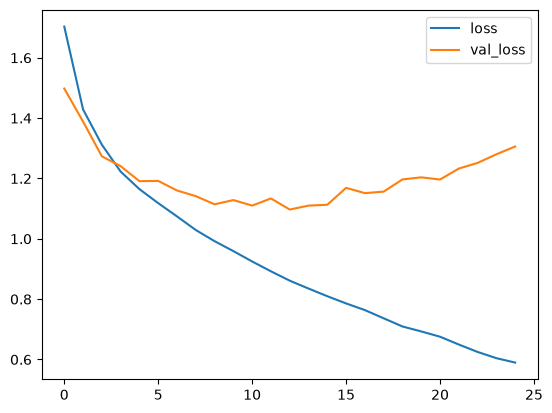

In [95]:
df[["loss","val_loss"]].plot(kind = "line")

In [79]:
y_pred = np.argmax(model.predict(X_test), axis =1 )

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step


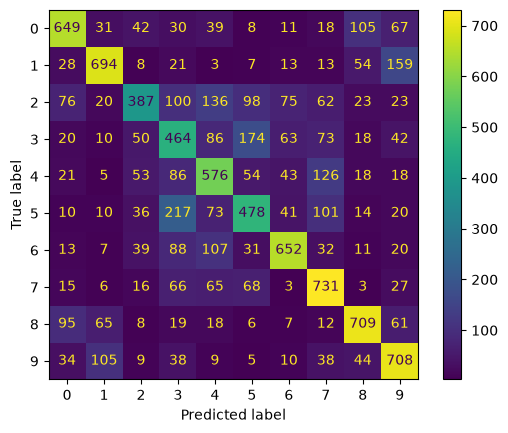

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

In [86]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [87]:
accuracy_score(y_test, y_pred)

0.6048

In [88]:
recall_score(y_test, y_pred, average = "macro")

0.6048

In [89]:
precision_score(y_test, y_pred, average = "macro")

0.6088713560529928

In [90]:
f1_score(y_test, y_pred, average = "macro")

0.6031309773176948